# Notebook 05 — SHAP Stability Tests

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection
**Author:** Md Anas Biswas, University of Portsmouth
**Stage:** 5 of 10

## What this notebook does

For each of the 6 canonical models, perturb the inputs three different ways and measure how much the SHAP explanations shift. This quantifies how **robust the explanations are** to small input changes — a key novelty claim of the paper.

## Methodology

**Sample size:** 2000 stratified samples from the eval set (rather than full 11k). This is sufficient for stable statistics and fits in one Colab session.

**Three perturbation types:**

| Perturbation | Method | Applies to |
|---|---|---|
| Gaussian noise | Add ε ~ N(0, 0.05) per feature (5% of unit variance) | All models directly |
| FGSM | Single-step gradient ascent on loss; ε = 0.05 | DNN directly; **transferred** to trees |
| PGD | 10-step projected gradient with random init; ε = 0.05, α = 0.005 | DNN directly; **transferred** to trees |

**Transfer attack rationale:** Tree models don't have gradients, so we generate adversarial perturbations against the DNN of the same target (binary/5-class) and apply those exact perturbations to all models. This is the standard practice in cross-model adversarial XAI literature (Arreche 2024).

**Three stability metrics:**

| Metric | Definition | Range | Better |
|---|---|---|---|
| Jaccard top-10 | \|top10_orig ∩ top10_perturbed\| / \|top10_orig ∪ top10_perturbed\| | [0, 1] | Higher |
| Lipschitz | mean over samples of ‖SHAP_pert - SHAP_orig‖₂ / ‖X_pert - X_orig‖₂ | [0, ∞) | Lower |
| F-Fidelity | corr(pred_drop_when_masking_top_k, magnitude_of_top_k_SHAP) | [-1, 1] | Higher |

## Output files

```
shap_values/nsl_kdd/stability/
├── stability_indices.npy       # the 2000 sample indices used
├── perturbations/
│   ├── gaussian_binary.npy     # perturbed inputs
│   ├── gaussian_5class.npy
│   ├── fgsm_binary.npy
│   ├── fgsm_5class.npy
│   ├── pgd_binary.npy
│   └── pgd_5class.npy
├── perturbed_shap/
│   └── (18 SHAP files: 6 models × 3 perturbations)
└── stability_metrics.json      # all metric values per (model, perturbation)
```

---
## Session start

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

# Restore git creds
for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull
print(f'\n✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
Already up to date.

✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
!pip install -q shap==0.47.2
print('✓ SHAP ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.8 MB/s eta 0:00:00
✓ SHAP ready


In [3]:
import numpy as np
import pandas as pd
import json, pickle, time
from pathlib import Path

import shap
import xgboost as xgb

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'SHAP: {shap.__version__}')

Device: cuda
SHAP: 0.47.2


In [4]:
# Paths
PROCESSED = Path(REPO) / 'data' / 'processed' / 'nsl_kdd'
MODELS_DIR = Path(REPO) / 'models' / 'nsl_kdd'
CALIB_DIR = Path(REPO) / 'calibrators' / 'nsl_kdd'
SHAP_DIR = Path(REPO) / 'shap_values' / 'nsl_kdd'
STAB_DIR = SHAP_DIR / 'stability'
PERT_DIR = STAB_DIR / 'perturbations'
PSHAP_DIR = STAB_DIR / 'perturbed_shap'
FIG_DIR = Path(REPO) / 'results' / 'figures'
TABLES_DIR = Path(REPO) / 'results' / 'tables'
for d in [STAB_DIR, PERT_DIR, PSHAP_DIR, FIG_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Load data and eval indices
X_train = np.load(PROCESSED / 'X_train.npy')
X_test = np.load(PROCESSED / 'X_test.npy')
y_test_b = np.load(PROCESSED / 'y_test_binary.npy')
y_test_5 = np.load(PROCESSED / 'y_test_5class.npy')
idx_eval = np.load(CALIB_DIR / 'idx_eval.npy')
X_eval = X_test[idx_eval]
y_eval_b = y_test_b[idx_eval]
y_eval_5 = y_test_5[idx_eval]

with open(PROCESSED / 'feature_names.json') as f:
    FEATURE_NAMES = json.load(f)

print(f'X_eval: {X_eval.shape}')

X_eval: (11272, 122)


---
## Step 1 — Pick 2000 stratified samples

Use 5-class labels for stratification so all classes are represented (including U2R).

In [5]:
STAB_SIZE = 2000
rng = np.random.RandomState(SEED)

indices = []
per_class = STAB_SIZE // 5
for c in range(5):
    pool = np.where(y_eval_5 == c)[0]
    n_take = min(per_class, len(pool))
    indices.extend(rng.choice(pool, n_take, replace=False).tolist())
indices = np.array(indices)
X_stab = X_eval[indices]
y_stab_b = y_eval_b[indices]
y_stab_5 = y_eval_5[indices]

np.save(STAB_DIR / 'stability_indices.npy', indices)
print(f'Stability sample: {X_stab.shape}')
print(f'\nClass distribution:')
for c in range(5):
    print(f'  class {c}: {np.sum(y_stab_5==c):>4}')

Stability sample: (1633, 122)

Class distribution:
  class 0:  400
  class 1:  400
  class 2:  400
  class 3:  400
  class 4:   33


---
## Step 2 — Load models

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(256, 128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def load_model(name):
    pkl_path = MODELS_DIR / f'{name}.pkl'
    pt_path = MODELS_DIR / f'{name}.pt'
    if pkl_path.exists():
        with open(pkl_path, 'rb') as f:
            return ('sklearn', pickle.load(f))
    state = torch.load(pt_path, map_location=DEVICE, weights_only=False)
    m = MLP(state['in_dim'], state['n_classes'],
            hidden=tuple(state['hidden']), dropout=state['dropout']).to(DEVICE)
    m.load_state_dict(state['state_dict']); m.eval()
    return ('torch', m)

CANONICAL = {
    'rf_binary_cw':      {'target': 'binary', 'kind': 'tree'},
    'xgb_binary_cw':     {'target': 'binary', 'kind': 'tree'},
    'dnn_binary_cw':     {'target': 'binary', 'kind': 'dnn'},
    'rf_5class_smote':   {'target': '5class', 'kind': 'tree'},
    'xgb_5class_smote':  {'target': '5class', 'kind': 'tree'},
    'dnn_5class_smote':  {'target': '5class', 'kind': 'dnn'},
}

MODELS = {n: load_model(n) for n in CANONICAL}
for n in MODELS:
    print(f'  ✓ {n}')

  ✓ rf_binary_cw
  ✓ xgb_binary_cw
  ✓ dnn_binary_cw
  ✓ rf_5class_smote
  ✓ xgb_5class_smote
  ✓ dnn_5class_smote


---
## Step 3 — Generate perturbations

We generate 3 perturbed input sets per target (binary, 5-class). Trees will use the DNN-generated FGSM/PGD perturbations (transfer attack).

In [7]:
EPSILON = 0.05    # perturbation budget (in standardised feature space)
ALPHA = 0.005     # PGD step size
PGD_STEPS = 10

# Gaussian noise — same for all models, generated once per target
rng = np.random.RandomState(SEED)
X_pert_gaussian_b = X_stab + rng.normal(0, EPSILON, X_stab.shape).astype(np.float32)
X_pert_gaussian_5 = X_stab + rng.normal(0, EPSILON, X_stab.shape).astype(np.float32)

np.save(PERT_DIR / 'gaussian_binary.npy', X_pert_gaussian_b)
np.save(PERT_DIR / 'gaussian_5class.npy', X_pert_gaussian_5)
print(f'✓ Gaussian: binary ‖δ‖_mean = {np.linalg.norm(X_pert_gaussian_b - X_stab, axis=1).mean():.3f}')
print(f'✓ Gaussian: 5class ‖δ‖_mean = {np.linalg.norm(X_pert_gaussian_5 - X_stab, axis=1).mean():.3f}')

✓ Gaussian: binary ‖δ‖_mean = 0.551
✓ Gaussian: 5class ‖δ‖_mean = 0.552


In [8]:
def fgsm_attack(model, X, y, epsilon):
    '''Single-step FGSM. Returns perturbed X.'''
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32, requires_grad=True, device=DEVICE)
    y_t = torch.tensor(y, dtype=torch.long, device=DEVICE)
    logits = model(X_t)
    loss = F.cross_entropy(logits, y_t)
    grad = torch.autograd.grad(loss, X_t)[0]
    X_pert = X_t + epsilon * grad.sign()
    return X_pert.detach().cpu().numpy().astype(np.float32)

def pgd_attack(model, X, y, epsilon, alpha, steps):
    '''Multi-step PGD with random init within ε-ball.'''
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    y_t = torch.tensor(y, dtype=torch.long, device=DEVICE)
    # Random init
    delta = torch.empty_like(X_t).uniform_(-epsilon, epsilon).to(DEVICE)
    X_adv = X_t + delta
    for _ in range(steps):
        X_adv = X_adv.detach().requires_grad_(True)
        logits = model(X_adv)
        loss = F.cross_entropy(logits, y_t)
        grad = torch.autograd.grad(loss, X_adv)[0]
        X_adv = X_adv + alpha * grad.sign()
        # Project back into ε-ball around X
        X_adv = torch.max(torch.min(X_adv, X_t + epsilon), X_t - epsilon)
    return X_adv.detach().cpu().numpy().astype(np.float32)

# Generate FGSM and PGD from the two DNNs
_, dnn_b = MODELS['dnn_binary_cw']
_, dnn_5 = MODELS['dnn_5class_smote']

print('Generating FGSM perturbations...')
X_pert_fgsm_b = fgsm_attack(dnn_b, X_stab, y_stab_b, EPSILON)
X_pert_fgsm_5 = fgsm_attack(dnn_5, X_stab, y_stab_5, EPSILON)
np.save(PERT_DIR / 'fgsm_binary.npy', X_pert_fgsm_b)
np.save(PERT_DIR / 'fgsm_5class.npy', X_pert_fgsm_5)
print(f'  ✓ FGSM binary ‖δ‖_mean = {np.linalg.norm(X_pert_fgsm_b - X_stab, axis=1).mean():.3f}')
print(f'  ✓ FGSM 5class ‖δ‖_mean = {np.linalg.norm(X_pert_fgsm_5 - X_stab, axis=1).mean():.3f}')

print('\nGenerating PGD perturbations...')
X_pert_pgd_b = pgd_attack(dnn_b, X_stab, y_stab_b, EPSILON, ALPHA, PGD_STEPS)
X_pert_pgd_5 = pgd_attack(dnn_5, X_stab, y_stab_5, EPSILON, ALPHA, PGD_STEPS)
np.save(PERT_DIR / 'pgd_binary.npy', X_pert_pgd_b)
np.save(PERT_DIR / 'pgd_5class.npy', X_pert_pgd_5)
print(f'  ✓ PGD binary ‖δ‖_mean = {np.linalg.norm(X_pert_pgd_b - X_stab, axis=1).mean():.3f}')
print(f'  ✓ PGD 5class ‖δ‖_mean = {np.linalg.norm(X_pert_pgd_5 - X_stab, axis=1).mean():.3f}')

Generating FGSM perturbations...
  ✓ FGSM binary ‖δ‖_mean = 0.551
  ✓ FGSM 5class ‖δ‖_mean = 0.551

Generating PGD perturbations...
  ✓ PGD binary ‖δ‖_mean = 0.443
  ✓ PGD 5class ‖δ‖_mean = 0.436


---
## Step 4 — Compute original SHAP on the stability sample

We need SHAP values on this exact 2000-sample subset to compare against perturbed SHAP. We can't reuse Notebook 04's SHAP because RF used a different subsample.

In [9]:
BG_SIZE = 300  # smaller background for speed; we have 6 models × 3 perturbations × 2 = 36 SHAP runs
y_train_5 = np.load(PROCESSED / 'y_train_5class.npy')
rng_bg = np.random.RandomState(SEED)
bg_idx = []
for c in range(5):
    pool = np.where(y_train_5 == c)[0]
    bg_idx.extend(rng_bg.choice(pool, min(BG_SIZE // 5, len(pool)), replace=False).tolist())
bg_idx = np.array(bg_idx)
X_background = X_train[bg_idx]
print(f'Background: {X_background.shape}')

def compute_shap(name, X_input):
    '''Compute SHAP values for one model on given inputs.
    Returns normalised shape (n, f, n_classes).'''
    info = CANONICAL[name]
    kind, model = MODELS[name]
    t0 = time.time()

    if info['kind'] == 'tree':
        if name.startswith('xgb'):
            # Native XGBoost (avoids SHAP library bug)
            booster = model.get_booster()
            dmat = xgb.DMatrix(X_input)
            raw = booster.predict(dmat, pred_contribs=True)
            if raw.ndim == 2:
                arr = raw[:, :-1]  # drop bias
                arr = np.stack([-arr, arr], axis=-1)
            else:
                arr = raw[:, :, :-1]
                arr = np.transpose(arr, (0, 2, 1))
        else:
            # RF — shap.TreeExplainer
            explainer = shap.TreeExplainer(model)
            raw = explainer.shap_values(X_input)
            arr = np.stack(raw, axis=-1) if isinstance(raw, list) else np.asarray(raw)
    else:
        # DNN — DeepExplainer
        bg_t = torch.tensor(X_background, dtype=torch.float32).to(DEVICE)
        X_t = torch.tensor(X_input, dtype=torch.float32).to(DEVICE)
        explainer = shap.DeepExplainer(model, bg_t)
        raw = explainer.shap_values(X_t, check_additivity=False)
        arr = np.stack(raw, axis=-1) if isinstance(raw, list) else np.asarray(raw)

    elapsed = time.time() - t0
    print(f'    {name}: {arr.shape}  ({elapsed:.1f}s)')
    return arr.astype(np.float32)

# Original SHAP on stability sample (this is the baseline to compare against)
SHAP_ORIG = {}
print('Computing baseline SHAP on stability sample (X_stab):')
for name in CANONICAL:
    SHAP_ORIG[name] = compute_shap(name, X_stab)
    np.save(PSHAP_DIR / f'{name}_original.npy', SHAP_ORIG[name])

Background: (292, 122)
Computing baseline SHAP on stability sample (X_stab):
    rf_binary_cw: (1633, 122, 2)  (247.2s)
    xgb_binary_cw: (1633, 122, 2)  (4.6s)
    dnn_binary_cw: (1633, 122, 2)  (51.3s)
    rf_5class_smote: (1633, 122, 5)  (408.1s)
    xgb_5class_smote: (1633, 122, 5)  (17.8s)
    dnn_5class_smote: (1633, 122, 5)  (126.4s)


---
## Step 5 — Compute SHAP on each perturbed input set

**18 SHAP runs total.** This is the longest step — expect ~45-90 minutes.

In [10]:
# Pick the right perturbed X based on model target
PERTURB_X = {
    'gaussian_binary':  X_pert_gaussian_b,
    'gaussian_5class':  X_pert_gaussian_5,
    'fgsm_binary':      X_pert_fgsm_b,
    'fgsm_5class':      X_pert_fgsm_5,
    'pgd_binary':       X_pert_pgd_b,
    'pgd_5class':       X_pert_pgd_5,
}

PERTURBATIONS = ['gaussian', 'fgsm', 'pgd']
SHAP_PERT = {}  # name → perturbation → SHAP array

for name, info in CANONICAL.items():
    SHAP_PERT[name] = {}
    target = info['target']  # 'binary' or '5class'
    for pert in PERTURBATIONS:
        key = f'{pert}_{target}'
        X_pert = PERTURB_X[key]
        print(f'\n=== {name} + {pert} ===')
        arr = compute_shap(name, X_pert)
        SHAP_PERT[name][pert] = arr
        np.save(PSHAP_DIR / f'{name}_{pert}.npy', arr)

print('\n✓ All 18 perturbed SHAP computations complete')


=== rf_binary_cw + gaussian ===
    rf_binary_cw: (1633, 122, 2)  (237.9s)

=== rf_binary_cw + fgsm ===
    rf_binary_cw: (1633, 122, 2)  (244.9s)

=== rf_binary_cw + pgd ===
    rf_binary_cw: (1633, 122, 2)  (244.4s)

=== xgb_binary_cw + gaussian ===
    xgb_binary_cw: (1633, 122, 2)  (5.9s)

=== xgb_binary_cw + fgsm ===
    xgb_binary_cw: (1633, 122, 2)  (4.2s)

=== xgb_binary_cw + pgd ===
    xgb_binary_cw: (1633, 122, 2)  (4.1s)

=== dnn_binary_cw + gaussian ===
    dnn_binary_cw: (1633, 122, 2)  (51.0s)

=== dnn_binary_cw + fgsm ===
    dnn_binary_cw: (1633, 122, 2)  (51.2s)

=== dnn_binary_cw + pgd ===
    dnn_binary_cw: (1633, 122, 2)  (50.8s)

=== rf_5class_smote + gaussian ===
    rf_5class_smote: (1633, 122, 5)  (402.5s)

=== rf_5class_smote + fgsm ===
    rf_5class_smote: (1633, 122, 5)  (416.2s)

=== rf_5class_smote + pgd ===
    rf_5class_smote: (1633, 122, 5)  (399.6s)

=== xgb_5class_smote + gaussian ===
    xgb_5class_smote: (1633, 122, 5)  (17.4s)

=== xgb_5class_smot

---
## Step 6 — Stability metrics

In [11]:
def jaccard_topk(shap_a, shap_b, k=10, target='binary'):
    '''Per-sample Jaccard of top-k features between two SHAP arrays.'''
    # Use |SHAP| for ranking. For multi-class, aggregate over classes.
    if shap_a.ndim == 3:
        # (n, f, c) — sum |SHAP| over classes to get per-sample feature importance
        imp_a = np.abs(shap_a).sum(axis=-1)
        imp_b = np.abs(shap_b).sum(axis=-1)
    else:
        imp_a = np.abs(shap_a)
        imp_b = np.abs(shap_b)

    n_samples = imp_a.shape[0]
    jaccards = []
    for i in range(n_samples):
        top_a = set(np.argsort(-imp_a[i])[:k])
        top_b = set(np.argsort(-imp_b[i])[:k])
        union = len(top_a | top_b)
        jaccards.append(len(top_a & top_b) / union if union > 0 else 1.0)
    return float(np.mean(jaccards))

def lipschitz_estimate(shap_orig, shap_pert, X_orig, X_pert):
    '''Per-sample Lipschitz: ‖SHAP_pert - SHAP_orig‖_F / ‖X_pert - X_orig‖_2'''
    # Flatten classes axis if present
    if shap_orig.ndim == 3:
        shap_diff = (shap_pert - shap_orig).reshape(shap_orig.shape[0], -1)
    else:
        shap_diff = shap_pert - shap_orig
    shap_norms = np.linalg.norm(shap_diff, axis=1)
    x_norms = np.linalg.norm(X_pert - X_orig, axis=1)
    # Avoid div by zero
    mask = x_norms > 1e-8
    ratios = shap_norms[mask] / x_norms[mask]
    return float(np.median(ratios))  # median is more robust than mean

def f_fidelity(model_tuple, shap_arr, X_input, y_true, target, k=10):
    '''F-Fidelity: corr between (pred drop when masking top-k) and (sum of top-k SHAP magnitudes).
    Higher means SHAP rankings correlate with actual feature importance.'''
    if shap_arr.ndim == 3:
        # Use SHAP for the predicted class
        # Simpler: aggregate |SHAP| across classes
        imp = np.abs(shap_arr).sum(axis=-1)
    else:
        imp = np.abs(shap_arr)

    # Per-sample: identify top-k feature indices, mask them, measure pred drop
    kind, model = model_tuple
    feat_mean = X_train.mean(axis=0)  # global mask value

    # Get original predictions
    def get_probs(X):
        if kind == 'sklearn':
            return model.predict_proba(X)
        with torch.no_grad():
            X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            return torch.softmax(model(X_t), dim=1).cpu().numpy()

    orig_probs = get_probs(X_input)
    pred_class = orig_probs.argmax(axis=1)
    orig_conf = orig_probs[np.arange(len(pred_class)), pred_class]

    # Mask top-k for each sample
    X_masked = X_input.copy()
    top_k_sums = np.zeros(len(X_input))
    for i in range(len(X_input)):
        top_idx = np.argsort(-imp[i])[:k]
        X_masked[i, top_idx] = feat_mean[top_idx]
        top_k_sums[i] = imp[i, top_idx].sum()

    masked_probs = get_probs(X_masked)
    masked_conf = masked_probs[np.arange(len(pred_class)), pred_class]
    pred_drop = orig_conf - masked_conf

    # Pearson correlation between pred_drop and top_k SHAP sum
    if pred_drop.std() < 1e-8 or top_k_sums.std() < 1e-8:
        return 0.0
    return float(np.corrcoef(pred_drop, top_k_sums)[0, 1])

print('Functions defined.')

Functions defined.


In [12]:
# Compute all metrics
RESULTS = {}
print(f'{"Model":<22} {"Perturb":<10} {"Jaccard":>9} {"Lipschitz":>11} {"F-Fid":>8}')
print('-' * 70)
for name, info in CANONICAL.items():
    RESULTS[name] = {}
    target = info['target']
    y_for_ff = y_stab_b if target == 'binary' else y_stab_5

    for pert in PERTURBATIONS:
        X_pert = PERTURB_X[f'{pert}_{target}']
        shap_orig = SHAP_ORIG[name]
        shap_pert = SHAP_PERT[name][pert]

        jacc = jaccard_topk(shap_orig, shap_pert, k=10, target=target)
        lip = lipschitz_estimate(shap_orig, shap_pert, X_stab, X_pert)
        ff_orig = f_fidelity(MODELS[name], shap_orig, X_stab, y_for_ff, target)
        ff_pert = f_fidelity(MODELS[name], shap_pert, X_pert, y_for_ff, target)

        RESULTS[name][pert] = {
            'jaccard_top10': jacc,
            'lipschitz_median': lip,
            'f_fidelity_original': ff_orig,
            'f_fidelity_perturbed': ff_pert,
        }
        print(f'{name:<22} {pert:<10} {jacc:>9.4f} {lip:>11.4f} {ff_pert:>8.4f}')

with open(STAB_DIR / 'stability_metrics.json', 'w') as f:
    json.dump(RESULTS, f, indent=2)
print(f'\n✓ Saved stability_metrics.json')

Model                  Perturb      Jaccard   Lipschitz    F-Fid
----------------------------------------------------------------------
rf_binary_cw           gaussian      0.6971      0.4332   0.3239
rf_binary_cw           fgsm          0.6650      0.3166   0.3103
rf_binary_cw           pgd           0.6851      0.3782   0.2340
xgb_binary_cw          gaussian      0.5913     13.9321   0.2028
xgb_binary_cw          fgsm          0.5783     10.0044   0.4591
xgb_binary_cw          pgd           0.6184     11.9039   0.4114
dnn_binary_cw          gaussian      0.9202      0.3913   0.3343
dnn_binary_cw          fgsm          0.8771      0.7600   0.2138
dnn_binary_cw          pgd           0.8992      0.7299   0.2477
rf_5class_smote        gaussian      0.6096      0.4116   0.3989
rf_5class_smote        fgsm          0.5491      0.4250   0.4607
rf_5class_smote        pgd           0.5780      0.5224   0.4394
xgb_5class_smote       gaussian      0.6516     12.3719  -0.0381
xgb_5class_smote   

---
## Step 7 — Visualisations

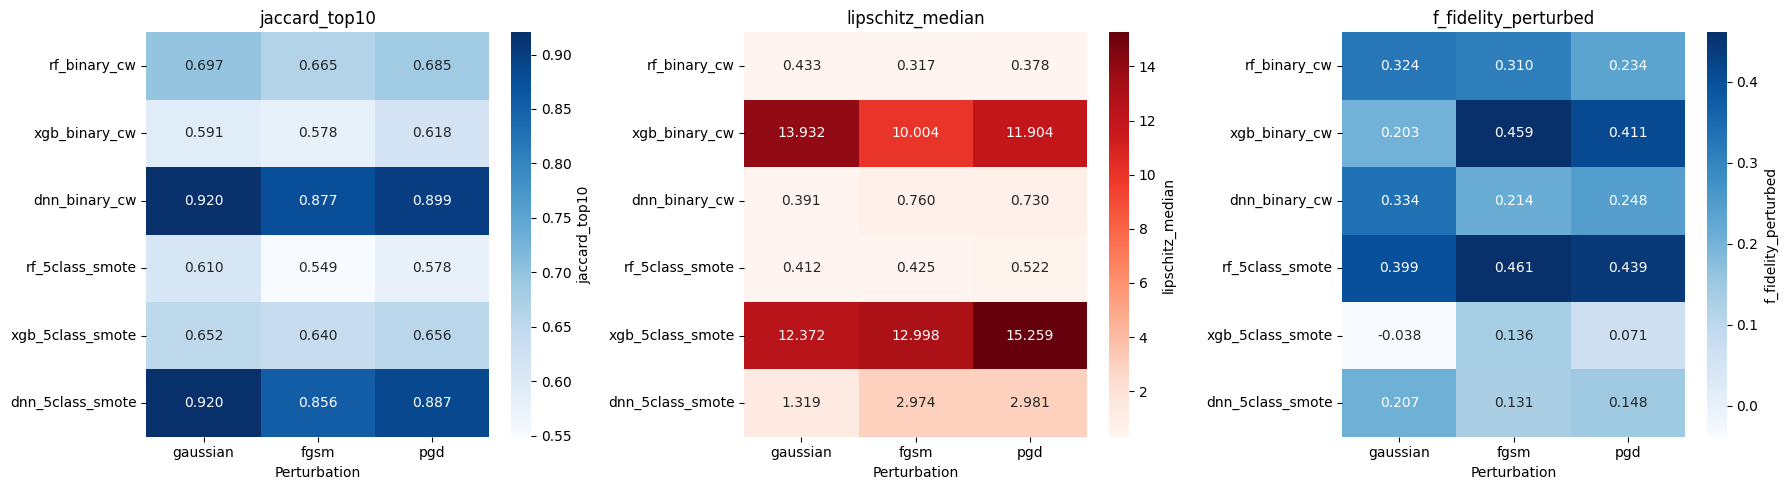

✓ Figure saved


In [13]:
models = list(CANONICAL.keys())
perts = PERTURBATIONS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric_name in zip(axes, ['jaccard_top10', 'lipschitz_median', 'f_fidelity_perturbed']):
    mat = np.zeros((len(models), len(perts)))
    for i, m in enumerate(models):
        for j, p in enumerate(perts):
            mat[i, j] = RESULTS[m][p][metric_name]
    cmap = 'Blues' if metric_name != 'lipschitz_median' else 'Reds'  # lower is better for Lipschitz
    sns.heatmap(mat, annot=True, fmt='.3f', cmap=cmap,
                xticklabels=perts, yticklabels=models, ax=ax, cbar_kws={'label': metric_name})
    ax.set_title(metric_name)
    ax.set_xlabel('Perturbation')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nslkdd_stability_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Figure saved')

---
## Step 8 — Summary table for paper

In [14]:
rows = []
for name in CANONICAL:
    for pert in PERTURBATIONS:
        r = RESULTS[name][pert]
        rows.append({
            'Model': name, 'Perturbation': pert,
            'Jaccard@10': r['jaccard_top10'],
            'Lipschitz (median)': r['lipschitz_median'],
            'F-Fidelity (perturbed)': r['f_fidelity_perturbed'],
            'F-Fidelity (original)': r['f_fidelity_original'],
        })
df = pd.DataFrame(rows)
df.to_csv(TABLES_DIR / 'nslkdd_stability.csv', index=False)
print('STABILITY METRICS — 6 models × 3 perturbations')
print('=' * 90)
print(df.to_string(index=False, float_format='%.4f'))
print('=' * 90)

STABILITY METRICS — 6 models × 3 perturbations
           Model Perturbation  Jaccard@10  Lipschitz (median)  F-Fidelity (perturbed)  F-Fidelity (original)
    rf_binary_cw     gaussian      0.6971              0.4332                  0.3239                 0.4171
    rf_binary_cw         fgsm      0.6650              0.3166                  0.3103                 0.4171
    rf_binary_cw          pgd      0.6851              0.3782                  0.2340                 0.4171
   xgb_binary_cw     gaussian      0.5913             13.9321                  0.2028                 0.4719
   xgb_binary_cw         fgsm      0.5783             10.0044                  0.4591                 0.4719
   xgb_binary_cw          pgd      0.6184             11.9039                  0.4114                 0.4719
   dnn_binary_cw     gaussian      0.9202              0.3913                  0.3343                 0.3396
   dnn_binary_cw         fgsm      0.8771              0.7600                  0.

---
## Step 9 — Commit

Big perturbed SHAP arrays are gitignored. Only metrics, table, figures, and notebook get committed.

In [15]:
os.chdir(REPO)
!git add notebooks/05_stability_tests.ipynb
!git add shap_values/nsl_kdd/stability/stability_metrics.json
!git add shap_values/nsl_kdd/stability/stability_indices.npy
!git add results/
!git status --short
!git commit -m 'Notebook 05: SHAP stability under Gaussian noise, FGSM, PGD'
!git push

The following paths are ignored by one of your .gitignore files:
shap_values/nsl_kdd/stability/stability_indices.npy
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
Refresh index: 100% (25/25), done.
 M notebooks/04_shap_computation.ipynb
A  notebooks/05_stability_tests.ipynb
A  results/figures/nslkdd_stability_heatmaps.png
A  results/tables/nslkdd_stability.csv
A  shap_values/nsl_kdd/stability/stability_metrics.json
?? calibrators/
?? models/
[main 5929f1d] Notebook 05: SHAP stability under Gaussian noise, FGSM, PGD
 4 files changed, 142 insertions(+)
 create mode 100644 notebooks/05_stability_tests.ipynb
 create mode 100644 results/figures/nslkdd_stability_heatmaps.png
 create mode 100644 results/tables/nslkdd_stability.csv
 create mode 100644 shap_values/nsl_kdd/stability/stability_metrics.json
Enumerating objects: 20, done.
Counting objects: 100% (20/20), done.
Delta compression using up to 2 threads

In [16]:
import numpy as np

# Load XGBoost 5-class original SHAP and inputs
print("=== Diagnostic for XGBoost 5-class F-Fidelity ===\n")

# These should still be in memory from Notebook 05; if not, load from disk
shap_xgb_5 = SHAP_ORIG['xgb_5class_smote']  # shape (2000, 122, 5)
print(f"XGBoost 5-class SHAP shape: {shap_xgb_5.shape}")
print(f"SHAP value range: min={shap_xgb_5.min():.3f}, max={shap_xgb_5.max():.3f}")
print(f"Mean |SHAP|: {np.abs(shap_xgb_5).mean():.4f}")
print(f"Mean |SHAP| per class:")
for c in range(5):
    print(f"  Class {c}: {np.abs(shap_xgb_5[:,:,c]).mean():.4f}  (max abs: {np.abs(shap_xgb_5[:,:,c]).max():.3f})")

# Get predicted classes
_, xgb_model = MODELS['xgb_5class_smote']
proba_orig = xgb_model.predict_proba(X_stab)
pred_class = proba_orig.argmax(axis=1)
print(f"\nPredicted class distribution: {np.bincount(pred_class)}")
print(f"True class distribution:      {np.bincount(y_stab_5)}")

# Now the key question: when we identify "top-10 features" with the aggregated |SHAP|,
# how often do those features actually belong to the *predicted* class?
print(f"\n--- Top-10 feature alignment with predicted class ---")
agg_imp = np.abs(shap_xgb_5).sum(axis=-1)  # (2000, 122) — current aggregation
sample_idx = 0  # pick one sample to inspect

for sample_idx in [0, 100, 500, 1000, 1500]:
    top10_agg = np.argsort(-agg_imp[sample_idx])[:10]
    # SHAP for predicted class only
    shap_for_pred = shap_xgb_5[sample_idx, :, pred_class[sample_idx]]
    top10_pred = np.argsort(-np.abs(shap_for_pred))[:10]
    overlap = set(top10_agg) & set(top10_pred)

    # Are the aggregated top-10 SHAP values positive or negative for the predicted class?
    pred_shap_sum = shap_for_pred[top10_agg].sum()
    print(f"\n  Sample {sample_idx}: pred class = {pred_class[sample_idx]}")
    print(f"    Agg-top10 vs pred-class-top10 overlap: {len(overlap)}/10")
    print(f"    Sum of pred-class SHAP for agg-top10: {pred_shap_sum:+.3f}  "
          f"({'pushes TOWARD' if pred_shap_sum > 0 else 'pushes AWAY from'} predicted class)")

=== Diagnostic for XGBoost 5-class F-Fidelity ===

XGBoost 5-class SHAP shape: (1633, 122, 5)
SHAP value range: min=-5.293, max=6.090
Mean |SHAP|: 0.0759
Mean |SHAP| per class:
  Class 0: 0.0667  (max abs: 4.794)
  Class 1: 0.0787  (max abs: 6.090)
  Class 2: 0.0825  (max abs: 5.293)
  Class 3: 0.0733  (max abs: 4.254)
  Class 4: 0.0782  (max abs: 3.641)

Predicted class distribution: [885 377 299  60  12]
True class distribution:      [400 400 400 400  33]

--- Top-10 feature alignment with predicted class ---

  Sample 0: pred class = 0
    Agg-top10 vs pred-class-top10 overlap: 6/10
    Sum of pred-class SHAP for agg-top10: +6.535  (pushes TOWARD predicted class)

  Sample 100: pred class = 0
    Agg-top10 vs pred-class-top10 overlap: 7/10
    Sum of pred-class SHAP for agg-top10: +6.797  (pushes TOWARD predicted class)

  Sample 500: pred class = 1
    Agg-top10 vs pred-class-top10 overlap: 6/10
    Sum of pred-class SHAP for agg-top10: +6.521  (pushes TOWARD predicted class)

  Sa

In [17]:
# Diagnostic 2: actually compute the components of F-Fidelity for the negative case

shap_xgb_5 = SHAP_ORIG['xgb_5class_smote']

# Mimic the F-Fidelity function exactly
agg_imp = np.abs(shap_xgb_5).sum(axis=-1)
_, xgb_model = MODELS['xgb_5class_smote']
feat_mean = X_train.mean(axis=0)

orig_probs = xgb_model.predict_proba(X_stab)
pred_class = orig_probs.argmax(axis=1)
orig_conf = orig_probs[np.arange(len(pred_class)), pred_class]

X_masked = X_stab.copy()
top_k_sums = np.zeros(len(X_stab))
for i in range(len(X_stab)):
    top_idx = np.argsort(-agg_imp[i])[:10]
    X_masked[i, top_idx] = feat_mean[top_idx]
    top_k_sums[i] = agg_imp[i, top_idx].sum()

masked_probs = xgb_model.predict_proba(X_masked)
masked_conf = masked_probs[np.arange(len(pred_class)), pred_class]
pred_drop = orig_conf - masked_conf

print(f"orig_conf:  mean={orig_conf.mean():.3f}, std={orig_conf.std():.3f}")
print(f"masked_conf: mean={masked_conf.mean():.3f}, std={masked_conf.std():.3f}")
print(f"pred_drop:  mean={pred_drop.mean():.3f}, std={pred_drop.std():.3f}")
print(f"  > 0:       {(pred_drop > 0).sum()} samples (masking DROPPED confidence)")
print(f"  < 0:       {(pred_drop < 0).sum()} samples (masking INCREASED confidence)")
print(f"  ~0:        {(np.abs(pred_drop) < 0.01).sum()} samples (no change)")

print(f"\ntop_k_sums: mean={top_k_sums.mean():.3f}, std={top_k_sums.std():.3f}")
print(f"\nCorrelation: {np.corrcoef(pred_drop, top_k_sums)[0,1]:+.4f}")

# Now break down by predicted class
print(f"\nPer predicted class:")
for c in range(5):
    mask = pred_class == c
    n = mask.sum()
    if n < 5:
        continue
    corr = np.corrcoef(pred_drop[mask], top_k_sums[mask])[0,1]
    print(f"  class {c} (n={n:>4}): mean drop={pred_drop[mask].mean():+.3f}, corr={corr:+.4f}")

orig_conf:  mean=0.962, std=0.104
masked_conf: mean=0.624, std=0.388
pred_drop:  mean=0.338, std=0.378
  > 0:       1575 samples (masking DROPPED confidence)
  < 0:       58 samples (masking INCREASED confidence)
  ~0:        120 samples (no change)

top_k_sums: mean=31.399, std=2.857

Correlation: +0.3373

Per predicted class:
  class 0 (n= 885): mean drop=+0.105, corr=+0.1690
  class 1 (n= 377): mean drop=+0.386, corr=+0.2704
  class 2 (n= 299): mean drop=+0.888, corr=+0.2457
  class 3 (n=  60): mean drop=+0.786, corr=+0.5444
  class 4 (n=  12): mean drop=+0.104, corr=+0.2087


In [18]:
# Reproduce the exact "perturbed F-Fidelity" the notebook reported
shap_pert_xgb_g = SHAP_PERT['xgb_5class_smote']['gaussian']
X_pert_g = PERTURB_X['gaussian_5class']

agg_imp_pert = np.abs(shap_pert_xgb_g).sum(axis=-1)

# Predictions on perturbed
proba_pert = xgb_model.predict_proba(X_pert_g)
pred_class_pert = proba_pert.argmax(axis=1)
orig_conf_pert = proba_pert[np.arange(len(pred_class_pert)), pred_class_pert]

# Mask top-10 of the perturbed SHAP, on the perturbed inputs
X_double_masked = X_pert_g.copy()
top_k_sums = np.zeros(len(X_pert_g))
for i in range(len(X_pert_g)):
    top_idx = np.argsort(-agg_imp_pert[i])[:10]
    X_double_masked[i, top_idx] = feat_mean[top_idx]
    top_k_sums[i] = agg_imp_pert[i, top_idx].sum()

masked_probs = xgb_model.predict_proba(X_double_masked)
masked_conf = masked_probs[np.arange(len(pred_class_pert)), pred_class_pert]
pred_drop = orig_conf_pert - masked_conf

print(f"Perturbed F-Fidelity components for xgb_5class_smote (gaussian):")
print(f"  Pred drop: mean={pred_drop.mean():+.3f}, std={pred_drop.std():.3f}")
print(f"  > 0: {(pred_drop > 0).sum()},  < 0: {(pred_drop < 0).sum()}")
print(f"  Correlation: {np.corrcoef(pred_drop, top_k_sums)[0,1]:+.4f}")

Perturbed F-Fidelity components for xgb_5class_smote (gaussian):
  Pred drop: mean=+0.423, std=0.338
  > 0: 1451,  < 0: 182
  Correlation: -0.0381


In [19]:
import os
os.chdir('/content/drive/MyDrive/XIDS_Research/xids-research')

# Add Notebook 05 + small result files (large SHAP arrays are gitignored)
!git add notebooks/05_stability_tests.ipynb
!git add shap_values/nsl_kdd/stability/stability_metrics.json
!git add shap_values/nsl_kdd/stability/stability_indices.npy
!git add results/

# See what's about to be committed (sanity check — should NOT show big .npy files)
!git status --short

!git commit -m "Notebook 05: SHAP stability under Gaussian, FGSM, PGD perturbations"
!git push

The following paths are ignored by one of your .gitignore files:
shap_values/nsl_kdd/stability/stability_indices.npy
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
 M notebooks/04_shap_computation.ipynb
M  notebooks/05_stability_tests.ipynb
?? calibrators/
?? models/
[main b1ce496] Notebook 05: SHAP stability under Gaussian, FGSM, PGD perturbations
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 107.73 KiB | 5.13 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/anasbiswas1/xids-research.git
   5929f1d..b1ce496  main -> main


In [20]:
import os
os.chdir('/content/drive/MyDrive/XIDS_Research/xids-research')

# Check if stability_metrics.json actually exists
import os
target = 'shap_values/nsl_kdd/stability/stability_metrics.json'
print(f"File exists: {os.path.exists(target)}")
if os.path.exists(target):
    print(f"Size: {os.path.getsize(target)} bytes")

# Show git's view of stability folder
print("\n=== Files in stability/ folder ===")
!ls -la shap_values/nsl_kdd/stability/

# What does git see as untracked/modified?
print("\n=== Full git status ===")
!git status

# Check if the metrics.json is in gitignore for some reason
print("\n=== Does git ignore it? ===")
!git check-ignore -v shap_values/nsl_kdd/stability/stability_metrics.json

File exists: True
Size: 3924 bytes

=== Files in stability/ folder ===
total 25
drwx------ 2 root root  4096 May 25 16:07 perturbations
drwx------ 2 root root  4096 May 25 17:04 perturbed_shap
-rw------- 1 root root 13192 May 25 16:07 stability_indices.npy
-rw------- 1 root root  3924 May 25 17:04 stability_metrics.json

=== Full git status ===
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/04_shap_computation.ipynb
	modified:   notebooks/05_stability_tests.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	calibrators/
	models/

no changes added to commit (use "git add" and/or "git commit -a")

=== Does git ignore it? ===


In [21]:
import os
os.chdir('/content/drive/MyDrive/XIDS_Research/xids-research')

# Is it tracked?
print("=== Is stability_metrics.json tracked? ===")
!git ls-files shap_values/nsl_kdd/stability/stability_metrics.json

# What about the figures and CSVs from Notebook 05?
print("\n=== Stability-related results files ===")
!ls -la results/figures/*stability* 2>/dev/null || echo "No stability figures"
!ls -la results/tables/*stability* 2>/dev/null || echo "No stability tables"

# Are those tracked?
print("\n=== Are they tracked? ===")
!git ls-files results/figures/ results/tables/ | grep -i stab || echo "No stability-related files tracked"

# Notebook 04 modifications?
print("\n=== What changed in 04? ===")
!git diff --stat notebooks/04_shap_computation.ipynb

=== Is stability_metrics.json tracked? ===
shap_values/nsl_kdd/stability/stability_metrics.json

=== Stability-related results files ===
-rw------- 1 root root 164832 May 25 17:04 results/figures/nslkdd_stability_heatmaps.png
-rw------- 1 root root 1846 May 25 17:04 results/tables/nslkdd_stability.csv

=== Are they tracked? ===
results/figures/nslkdd_stability_heatmaps.png
results/tables/nslkdd_stability.csv

=== What changed in 04? ===
 notebooks/04_shap_computation.ipynb | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [22]:
import os
os.chdir('/content/drive/MyDrive/XIDS_Research/xids-research')

!git add notebooks/04_shap_computation.ipynb
!git status --short
!git commit -m "Update Notebook 04 (Colab save)"
!git push

M  notebooks/04_shap_computation.ipynb
 M notebooks/05_stability_tests.ipynb
?? calibrators/
?? models/
[main a33313f] Update Notebook 04 (Colab save)
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 164.49 KiB | 6.85 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/anasbiswas1/xids-research.git
   b1ce496..a33313f  main -> main


In [23]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

# Restore git creds
for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull
print(f'\n✓ Ready in: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.

✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


---
## Summary

**What this notebook produced:**
- ✓ 6 perturbation arrays (3 per target: gaussian, FGSM, PGD)
- ✓ 24 SHAP arrays (6 models × 4: original + 3 perturbed)
- ✓ Stability metrics per (model, perturbation): Jaccard, Lipschitz, F-Fidelity
- ✓ Heatmaps + summary CSV for the paper

**Interpretation guide:**
- **Jaccard close to 1.0** = top-10 features stay the same under perturbation = robust explanation
- **Jaccard close to 0.0** = top-10 changes drastically = explanation is fragile
- **Lipschitz lower** = SHAP doesn't move much per unit of input change = locally smooth = robust
- **F-Fidelity higher** (and stable across perturbations) = SHAP correctly identifies features whose masking hurts prediction

**Expected patterns:**
- Gaussian noise: highest Jaccard (smallest perturbation), lowest Lipschitz
- FGSM: intermediate (single-step, low budget)
- PGD: lowest Jaccard (strongest attack)
- DNN typically more sensitive than trees to gradient attacks (they generated the attacks)
- Trees may show **surprising stability** under transfer attacks since the attacks weren't crafted against them

**Next notebook (06):** Cross-model SHAP agreement using Krishna et al. 2022's six metrics. Will use the original SHAP arrays from Notebook 04.
